# 反応器の圧力損失と形式選択 — 軸流深床 → 径方向流

**目的**: 反応器設計レビュー(2026-05-30)で「0.5 bar 低圧固定床では圧力損失を無視できない」と指摘を受けた。
本ノートはその経緯をレポート用に 1 冊へまとめる。

物語:
1. **(a) 旧モデル**: 軸流・深い充填層 PFR。**圧損ゼロ**を仮定していた。
2. **(b) 本日の発見**: Ergun 式を軸方向 ODE に連成すると、触媒モデルで妥当な粒径(~3mm)では
   現 `main.py` 探索域 (z_cat 15–40m) の反応器は **全て ΔP 過大で infeasible**。
3. **(c) 物理的な解**: 径方向流(radial flow)ベッド。触媒量を塔高で、圧損を薄い床厚で**分離**できる。
4. **(d) 結論**: 0.5 bar 低圧は**平衡転化率のため不可欠**(後述)→ 圧力では妥協できない →
   よって **0.5 bar 低圧 PDH は径方向流ベッドが必然**。実機 Oleflex/Catofin と同じ設計思想に物理で到達する。

> 注: (a)(b) は本ノートで定量化する。(c)(d) は概念整理(径方向流モデルは別途 `units/reactors/` に追加予定)。


## 補足: 反応の性質と反応器の分類 (レポートの厚み用)

**PDH 反応器は「触媒固定床反応器(catalytic fixed-bed)」に分類される。ラジカル反応器ではない。**
反応器の分類は**目的反応のメカニズム**で決まり、PDH の目的反応=触媒脱水素(Cr₂O₃ 表面で進む)だから。

- 「固定床でラジカル反応は無理」という直感は、**純粋な気相ラジカル反応(熱分解=スチームクラッキング等)については概ね正しい**:
  触媒は寄与せず無意味で、充填物が壁面失活(ラジカル再結合)を促し ΔP/コーキングだけ増えるため、実機は**空の加熱管(クラッキング炉)**を使い充填床は使わない。
- ただし**高温容器の空隙では熱的ラジカル反応は勝手に起きる**。PDH ではそれが副反応 r2(クラッキング)。つまり PDH 固定床内で
  「触媒表面=脱水素(目的) / 粒子間空隙=少量の気相ラジカルクラッキング(寄生的損失)」が同時進行する。だが反応器の役割は触媒脱水素なので分類は触媒反応器。
- 厳密には OCM(触媒表面でラジカル生成→気相で反応)のような固定床ハイブリッドもあるので「不可能」ではなく「純ラジカル反応では普通やらない」が正確。

そして「固定床でラジカル反応は難しい(ホットスポット・熱暴走)」という発熱系の一般論も、**PDH 主反応には当てはまらない**:

| 反応 | 性質 | モデル |
|---|---|---|
| r1: C₃H₈→C₃H₆+H₂ (**主・目的**) | **触媒**脱水素・**吸熱** | 活性係数 `a` あり(触媒依存) |
| r2: C₃H₈→C₂H₄+CH₄ (副・クラッキング) | **気相ラジカル(熱分解)** | `r2=k₂·P_A`、`a` **なし**(触媒非依存=熱的) |
| r3: C₂H₄+H₂→C₂H₆ (副・水素化) | 気相/逐次 | `a` なし |

- 目的の脱水素は**触媒反応**であり、ホットスポット/熱暴走の悩みは**発熱ラジカル反応(OCM等)の話**。
  PDH 主反応は**強吸熱**(ΔH≈+124 kJ/mol)で床は**冷える** → 反応中はホットスポットも暴走も起きない
  (悩みは逆で「冷えて平衡転化率が頭打ち」)。
- ラジカル/発熱の懸念が効くのは **(i) クラッキング副反応の選択率**(低温・低圧・短滞留で抑制 → 0.5 bar が選択率にも効く)と
  **(ii) コーク燃焼=再生工程**(強発熱・ホットスポット本丸。ただし現モデルは再生動特性を持たない=スコープ外)。
- 結論: **PDH は触媒+吸熱なので固定床(軸流/径方向流)が標準で妥当**。形式の選択は **圧力損失**で決まる。


In [1]:
import sys, os, math, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# プロジェクトルートを探して import path に追加 (cwd が monitor/ でも root でも動く)
_ROOT = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_ROOT, 'units')):
        break
    _ROOT = os.path.dirname(_ROOT)
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from src.thermo import PDHThermo
from units.reactors.swing import (
    DesignVars, FeedStream, FixedParams, simulate_swing_reactor_system,
    _ode_axial, _COMPS, calc_a,
)

# 代表的な反応器入口ストリーム (リサイクル込み, 設計書 ~6400 kmol/h 規模)
FEED = FeedStream(
    F_in={'A': 5200., 'B': 700., 'C': 200., 'D': 50., 'E': 30., 'F': 13.},
    T_feed=303.15, P_in=50000.,  # 0.5 bar abs (contest 規定)
)
print('reactor inlet total =', sum(FEED.F_in.values()), 'kmol/h,  P_in =', FEED.P_in/1e5, 'bar')
print('default FixedParams:', f"d_p={FixedParams().d_p_m*1e3:.1f}mm, eps_bed={FixedParams().eps_bed}, "
      f"phi={FixedParams().sphericity}, dP/P_max={FixedParams().dP_over_P_max}")

reactor inlet total = 6193.0 kmol/h,  P_in = 0.5 bar
default FixedParams: d_p=3.0mm, eps_bed=0.4, phi=0.9, dP/P_max=0.1


## なぜ 0.5 bar か — 平衡転化率のため

PDH 主反応は **C₃H₈ → C₃H₆ + H₂ (1分子→2分子)** のモル数増加反応。ルシャトリエの原理で**低圧ほど生成側**へ進む。
プロジェクトの熱力学(`PDHThermo.calc_keq`)で純プロパン基準の平衡転化率を圧力ごとに計算する。


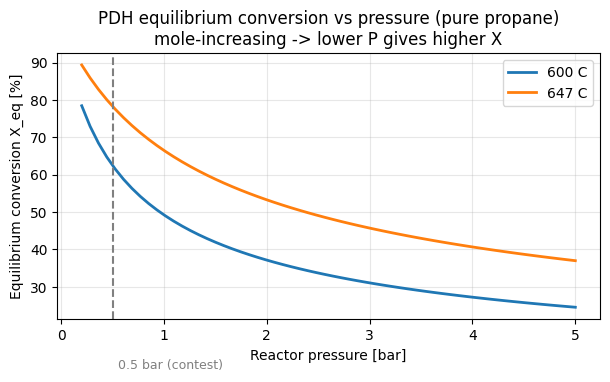

T=600C: 0.3bar->72%  0.5bar->62%  1.0bar->49%  2.0bar->37%  5.0bar->25%
T=647C: 0.3bar->85%  0.5bar->78%  1.0bar->66%  2.0bar->53%  5.0bar->37%


In [2]:
th = PDHThermo()
Ps = np.linspace(0.2, 5.0, 60)
fig, ax = plt.subplots(figsize=(6.2, 4.0))
for T in (873.15, 920.0):
    Keq = th.calc_keq(T)                 # [Pa]
    r = Keq / (Ps * 1e5)                 # X^2/(1-X^2) = Keq/P
    X = np.sqrt(r / (1.0 + r))
    ax.plot(Ps, X*100, '-', lw=2, label=f'{T-273.15:.0f} C')
ax.axvline(0.5, ls='--', c='gray')
ax.text(0.55, 8, '0.5 bar (contest)', color='gray', fontsize=9)
ax.set_xlabel('Reactor pressure [bar]')
ax.set_ylabel('Equilibrium conversion X_eq [%]')
ax.set_title('PDH equilibrium conversion vs pressure (pure propane)\nmole-increasing -> lower P gives higher X')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

for T in (873.15, 920.0):
    Keq = th.calc_keq(T)
    print(f'T={T-273.15:.0f}C:', '  '.join(
        f'{p}bar->{math.sqrt((Keq/(p*1e5))/(1+Keq/(p*1e5)))*100:.0f}%' for p in (0.3,0.5,1.0,2.0,5.0)))

## (a)+(b) 軸流深床 PFR に Ergun 圧損を連成

軸方向 ODE の状態に全圧 $P$ を追加し、

$$\frac{dP}{dz} = -\left[150\,\frac{(1-\varepsilon_b)^2\,\mu\,u}{\varepsilon_b^3 (\phi d_p)^2} + 1.75\,\frac{(1-\varepsilon_b)\,\rho\,u^2}{\varepsilon_b^3\,\phi d_p}\right]$$

で減衰させる。$u$=1基あたり空塔速度 $=Q_{vol}/(A\,N_{parallel})$、$\rho$=理想気体組成平均密度、$\mu$=ガス粘度(!仮置き近似)。
分圧も局所 $P$ で評価する(P–T–組成–流量の完全連成)。

**まず軸方向プロファイル**を見る。粒径 3/6/20 mm で $P(z)$ がどう減衰するか(0.5bar は低圧なので
$\rho\propto P,\,u\propto 1/P$ で慣性項が暴走 → 深床では数 m で圧力が落ちきる=チョーキング)。


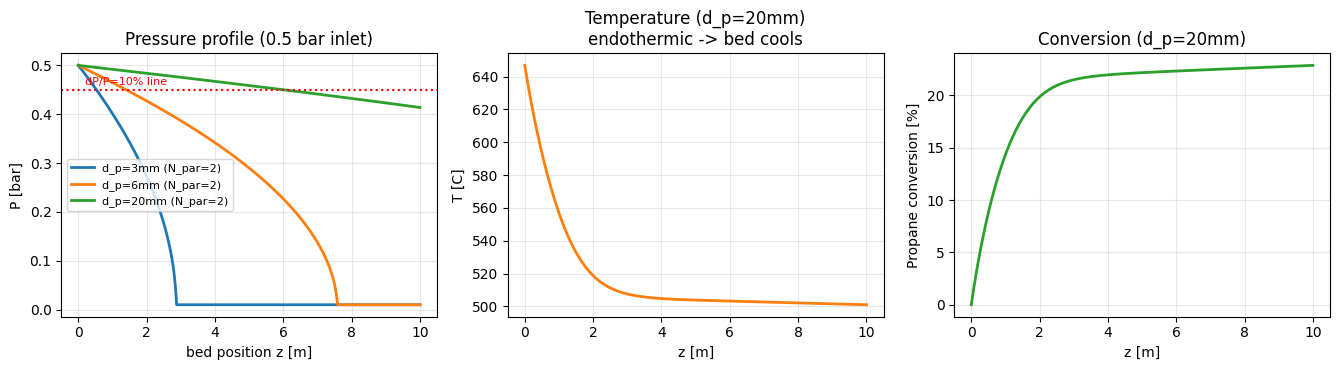

In [3]:
def axial_profile(T_in, z_cat, D, d_p_m, feed=FEED, t_min=0.0,
                  eps=0.5, eps_bed=0.40, phi=0.9, V_cat_max=200.0):
    # 単一設計の軸方向プロファイル (sol.t=z, sol.y=[F(6),T,P]) を返す。
    A = math.pi/4*D**2
    Vcat = A*z_cat*(1-eps)
    Np = max(math.ceil(Vcat/V_cat_max), 1)
    a = calc_a(t_min, T_in, feed.P_in)
    F0 = np.array([feed.F_in.get(c, 0.)*1000/3600 for c in _COMPS])
    y0 = np.concatenate([F0, [T_in], [feed.P_in]])
    zev = np.linspace(0, z_cat, 300)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sol = solve_ivp(lambda z, y: _ode_axial(z, y, a, A, eps, eps_bed, d_p_m, phi, Np),
                        (0, z_cat), y0, method='Radau', rtol=1e-4, atol=1e-7, t_eval=zev)
    return sol, Np, F0

T_in, D, z_cat = 920.0, 10.0, 10.0
fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8))
for d_p in (0.003, 0.006, 0.020):
    sol, Np, F0 = axial_profile(T_in, z_cat, D, d_p)
    axs[0].plot(sol.t, sol.y[7]/1e5, lw=2, label=f'd_p={d_p*1e3:.0f}mm (N_par={Np})')
axs[0].axhline(0.45, ls=':', c='r'); axs[0].text(0.2, 0.46, 'dP/P=10% line', color='r', fontsize=8)
axs[0].set_xlabel('bed position z [m]'); axs[0].set_ylabel('P [bar]')
axs[0].set_title('Pressure profile (0.5 bar inlet)'); axs[0].legend(fontsize=8); axs[0].grid(alpha=.3)

sol, Np, F0 = axial_profile(T_in, z_cat, D, 0.020)
axs[1].plot(sol.t, sol.y[6]-273.15, 'C1', lw=2)
axs[1].set_xlabel('z [m]'); axs[1].set_ylabel('T [C]')
axs[1].set_title('Temperature (d_p=20mm)\nendothermic -> bed cools'); axs[1].grid(alpha=.3)
X = (F0[0]-sol.y[0])/F0[0]*100
axs[2].plot(sol.t, X, 'C2', lw=2)
axs[2].set_xlabel('z [m]'); axs[2].set_ylabel('Propane conversion [%]')
axs[2].set_title('Conversion (d_p=20mm)'); axs[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### (b) Feasibility マップ — 粒径 × 床長

各 (d_p, z_cat) で反応器を実走し、判定を色分け:
- **緑 = feasible** (ΔP/P ≤ 10% かつ SV ∈ [0.5, 3] m/s)
- **赤 = ΔP/P > 10%** (圧損過大)
- **橙 = SV 範囲外** (短床で並列基数↓ → 流速過大 / 超長床で流速過小)

セル内の数字は ΔP/P [%]。`main.py` の現探索域 z_cat=15–40m を縦線で示す。


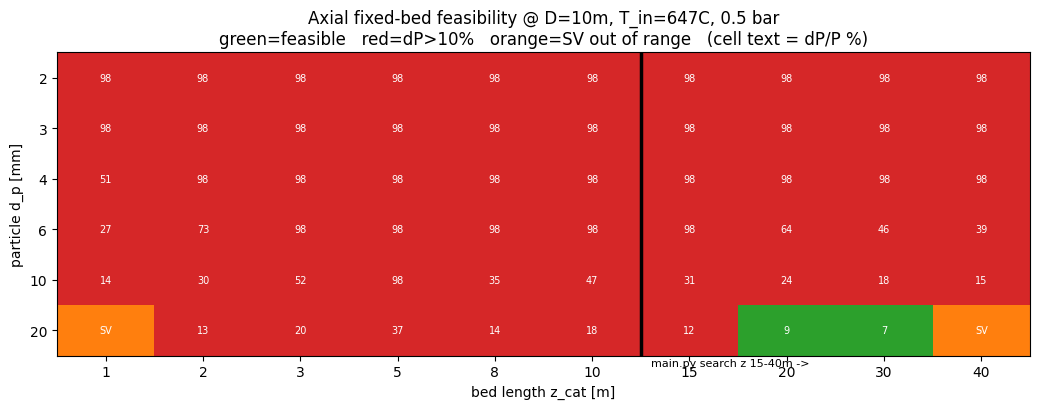

現実的な触媒粒径 (2-6mm) で feasible なセル数 / 全セル = 0 / 40
現探索域 z_cat=15-40m (全 d_p) で feasible なセル数 = 2


In [4]:
d_ps_mm = [2, 3, 4, 6, 10, 20]
z_cats  = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40]
D, T_in = 10.0, 920.0

status = np.zeros((len(d_ps_mm), len(z_cats)), dtype=int)   # 0 ok, 1 dP, 2 SV, 3 other
dpgrid = np.full(status.shape, np.nan)
for i, dp in enumerate(d_ps_mm):
    for j, z in enumerate(z_cats):
        fx = FixedParams(d_p_m=dp/1000.)
        d = DesignVars(T_in=T_in, z_cat=float(z), t_cyc=15., D=D)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r = simulate_swing_reactor_system(d, FEED, fx)
        reason = r.equipment.penalty_reason
        dpgrid[i, j] = r.equipment.dP_over_P_actual*100
        status[i, j] = {'': 0, 'dP_excess': 1, 'sv_out_of_range': 2}.get(reason, 3)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f'])
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.imshow(status, cmap=cmap, vmin=0, vmax=3, aspect='auto')
ax.set_xticks(range(len(z_cats))); ax.set_xticklabels(z_cats)
ax.set_yticks(range(len(d_ps_mm))); ax.set_yticklabels(d_ps_mm)
ax.set_xlabel('bed length z_cat [m]'); ax.set_ylabel('particle d_p [mm]')
ax.set_title(f'Axial fixed-bed feasibility @ D={D:.0f}m, T_in={T_in-273.15:.0f}C, 0.5 bar\n'
             'green=feasible   red=dP>10%   orange=SV out of range   (cell text = dP/P %)')
for i in range(len(d_ps_mm)):
    for j in range(len(z_cats)):
        t = (f'{dpgrid[i,j]:.0f}' if status[i,j] in (0, 1) else ('SV' if status[i,j]==2 else '?'))
        ax.text(j, i, t, ha='center', va='center', color='white', fontsize=7)
ax.axvline(z_cats.index(15)-0.5, color='k', lw=2.5)
ax.text(z_cats.index(15)-0.4, len(d_ps_mm)-0.3, 'main.py search z 15-40m ->', fontsize=8)
plt.tight_layout(); plt.show()

real = [d_ps_mm.index(x) for x in (2, 3, 4, 6)]
print('現実的な触媒粒径 (2-6mm) で feasible なセル数 / 全セル =',
      int((status[real, :] == 0).sum()), '/', len(real)*len(z_cats))
print('現探索域 z_cat=15-40m (全 d_p) で feasible なセル数 =',
      int((status[:, [z_cats.index(z) for z in (15,20,30,40)]] == 0).sum()))

### (a)+(b) の所見

- 現実的な粒径(2–6mm)では、**どの床長でも軸流深床は 0.5 bar で成立しない**(緑がほぼ無い)。
- **短床は橙(SV 過大)**: 床が短い→必要触媒体積が小さい→並列基数 N_par が減る→1基あたり流速↑→SV>3。
- **長床は赤(ΔP 過大)**: 流路長が長い→圧損が入口圧の数十%〜全損。
- 救えるのは**数十 mm の大粒径**だが、それは(i)メーカー供給範囲外、(ii)粒内拡散律速でキネティクス前提が崩れる、
  (iii)失活も粒径依存になる、ため**物理的に正当化できない**。
- ⇒ **軸流深床 PFR では 0.5 bar PDH は実現不可**。SV と ΔP の板挟み(squeeze)が本質。


## (c)+(d) 物理的な解 = 径方向流ベッド / 結論

圧力(=平衡転化率)で妥協できない以上、残るレバーは**反応器の幾何**。

| | 軸流・深床(現行) | 径方向流(radial flow) |
|---|---|---|
| 流れの向き | 軸方向 z | **半径方向 r** |
| 圧損を決める流路長 | 床長 z_cat(長い) | 床**厚さ** Δr(薄い ~0.3–1m) |
| 流路断面積 | $A=\pi D^2/4$(一定) | $A(r)=2\pi r H$(大・r 依存) |
| 触媒体積 | $A\cdot z_{cat}$ | $\pi(r_o^2-r_i^2)H$ |
| ΔP | **大** | **小**(短流路+大面積) |
| 肝 | 体積と圧損が結合 | **体積(塔高 H)と圧損(床厚 Δr)を分離できる** |

- 径方向流は、ガスを薄い環状床に**横向きに短く**通すので、流路長が数十 cm で済み ΔP が桁で下がる。
  触媒量は塔高 H で別途稼げる。→ **体積と圧損のトレードオフを解消**。
- これは実機 **UOP Oleflex(径方向流)** や **Lummus Catofin(減圧・浅床)** が採る設計思想そのもの。

**結論(d)**: 0.5 bar 低圧は平衡転化率のため不可欠 → 圧力では逃げられない → 軸流深床では圧損で破綻 →
**0.5 bar 低圧 PDH は径方向流(または浅床)ベッドが必然**。圧損を物理で入れたことで、実機の設計思想に到達した。

> 実装: `units/reactors/radial_flow.py` を **新規追加**(現 `swing.py` 軸流モデルは温存)。物理(速度式・
> 熱力学・Ergun・コスト・出力 dataclass)は swing から import して共有し、幾何だけ径方向に差し替えた。


### 検証: 径方向流モデルを実装して実証

`units/reactors/radial_flow.py`(同一 `SimulationResult` を返す)を実走し、**現実的な 3mm 粒**で
径方向流が feasible になることを確認する。さらに **同一 V_cat** で軸流(非現実 50mm)と径方向(現実 3mm)を
比較し、「**転化率は同じ・ΔP だけが激減**(= 径方向流は圧損だけを救う)」を定量で示す。


径方向流 (d_p=3mm) feasibility:
  Di=5.0 dr=0.5 H=  10m -> ok   dP/P= 8.2% X= 7.7% S=84.0%
  Di=6.0 dr=0.5 H=  15m -> ok   dP/P= 3.5% X=11.9% S=84.9%


  Di=5.0 dr=0.8 H=  20m -> ok   dP/P= 4.4% X=17.1% S=85.9%
  Di=4.0 dr=1.0 H=  25m -> ok   dP/P= 5.1% X=19.4% S=86.3%


  Di=6.0 dr=0.5 H=  30m -> ok   dP/P= 1.4% X=17.5% S=86.0%



同一 V_cat=314 m3:
  axial  d_p=50mm: X=22.6% S=86.7% dP/P=4.9%
  radial d_p= 3mm: X=22.6% S=86.6% dP/P=0.3%  (H=73m)


Z:\pdh_simulator\src\cost_calculator.py:128: UserWarning: calc_cp0: A=1028.158 m³ は推算式の適用範囲 [0.3, 520.0] m³ 外です。
  cp0 = calc_cp0(V_vessel_m3)


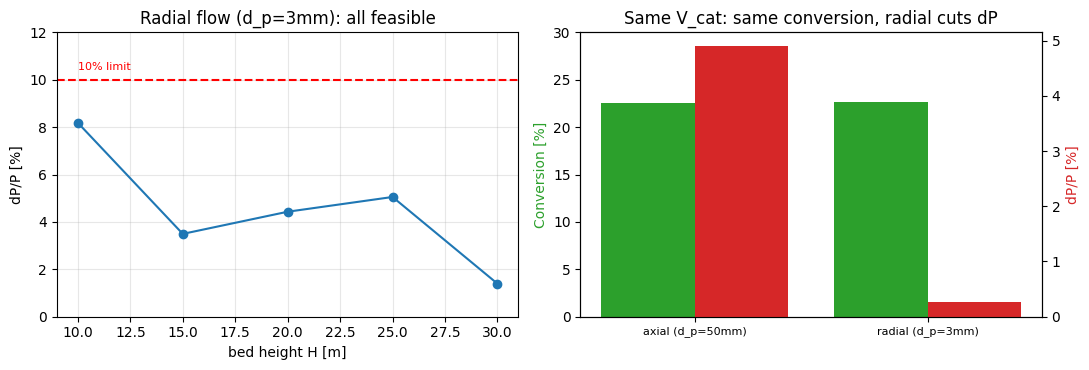

In [5]:
from units.reactors.swing import DesignVars as AxialDesign
from units.reactors.radial_flow import RadialDesignVars, simulate_radial_flow_reactor_system

fx3 = FixedParams()  # d_p=3mm (現実的)
radial_cases = [(5.0, 0.5, 10.), (6.0, 0.5, 15.), (5.0, 0.8, 20.), (4.0, 1.0, 25.), (6.0, 0.5, 30.)]
print('径方向流 (d_p=3mm) feasibility:')
Hs, dPs = [], []
for Di, dr, H in radial_cases:
    d = RadialDesignVars(T_in=920., t_cyc=15., D_inner=Di, bed_thickness=dr, H=H)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = simulate_radial_flow_reactor_system(d, FEED, fx3)
    eq = r.equipment; reason = eq.penalty_reason or 'ok'
    print(f"  Di={Di} dr={dr} H={H:4.0f}m -> {reason:4s} dP/P={eq.dP_over_P_actual*100:4.1f}% "
          f"X={r.performance.Conversion:4.1f}% S={r.performance.Selectivity:4.1f}%")
    Hs.append(H); dPs.append(eq.dP_over_P_actual*100)

# 決定的比較: 同一 V_cat で 軸流(d_p=50mm 非現実) vs 径方向(d_p=3mm 現実)
Vtarget = math.pi/4*10**2*8*(1-0.5)
axr = simulate_swing_reactor_system(AxialDesign(T_in=920., z_cat=8., t_cyc=15., D=10.),
                                    FEED, FixedParams(d_p_m=0.050))
Hm = Vtarget/(math.pi*(3.0**2-2.5**2)*(1-0.5))
rdr = simulate_radial_flow_reactor_system(
    RadialDesignVars(T_in=920., t_cyc=15., D_inner=5.0, bed_thickness=0.5, H=Hm), FEED, fx3)
print(f"\n同一 V_cat={Vtarget:.0f} m3:")
print(f"  axial  d_p=50mm: X={axr.performance.Conversion:.1f}% S={axr.performance.Selectivity:.1f}% "
      f"dP/P={axr.equipment.dP_over_P_actual*100:.1f}%")
print(f"  radial d_p= 3mm: X={rdr.performance.Conversion:.1f}% S={rdr.performance.Selectivity:.1f}% "
      f"dP/P={rdr.equipment.dP_over_P_actual*100:.1f}%  (H={Hm:.0f}m)")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
axs[0].plot(Hs, dPs, 'o-', c='C0')
axs[0].axhline(10, ls='--', c='r'); axs[0].text(10, 10.4, '10% limit', color='r', fontsize=8)
axs[0].set_xlabel('bed height H [m]'); axs[0].set_ylabel('dP/P [%]'); axs[0].set_ylim(0, 12)
axs[0].set_title('Radial flow (d_p=3mm): all feasible'); axs[0].grid(alpha=.3)
labels = ['axial (d_p=50mm)', 'radial (d_p=3mm)']; xpos = np.arange(2)
ax2 = axs[1]; ax2b = ax2.twinx()
ax2.bar(xpos-0.2, [axr.performance.Conversion, rdr.performance.Conversion], 0.4, color='C2')
ax2b.bar(xpos+0.2, [axr.equipment.dP_over_P_actual*100, rdr.equipment.dP_over_P_actual*100], 0.4, color='C3')
ax2.set_xticks(xpos); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Conversion [%]', color='C2'); ax2b.set_ylabel('dP/P [%]', color='C3')
ax2.set_title('Same V_cat: same conversion, radial cuts dP'); ax2.set_ylim(0, 30)
plt.tight_layout(); plt.show()

### まとめ

- 同一 V_cat で **転化率・選択率は軸流と一致**(空間時間が同じ)、しかし **ΔP は径方向流が桁で小さい**
  → 径方向流は「圧損だけ」を救い、化学(転化率・選択率)は犠牲にしない。
- **現実的な 3mm 触媒で 0.5 bar 径方向流が成立** → 低圧の平衡メリットを保ったまま圧損問題を解決。
- ⇒ レポート結論: **0.5 bar 低圧 PDH は径方向流(または浅床)が物理的必然**。実機 Oleflex/Catofin と一致。

次ステップ(任意): `run_one_pass` が軸流/径方向流をフラグで選べるよう配線し、径方向流の幾何
(D_inner, bed_thickness, H)を BO の設計変数に追加すれば、径方向流前提で全系再最適化ができる。
